# Usage Example of Pyspectrum
pyspectrum is a package that helps with handeling spectra.\
The package includes spectrum realization via xarray and other standard python tools.\
In here, the basic use of PySpectrum is presented.\
We'll load a spectrum and calibrate it and normlized it.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create calibrated Spectrum 
from pyspectrum.core import Spectrum, Domain
from pyspectrum.io import TimeChannelParser
from pyspectrum.calibration.models.hpge_fwhm_model import StandardHPGeFWHMModel
from pyspectrum.calibration import AxisCalibration, ResolutionCalibration
from pyspectrum.calibration.detector_calibration import DetectorCalibration, StandardHPGeFWHMModel, PolynomialEnergyModel

from pyspectrum.domain_characterization.morphology import peak_positions, find_domain_peaks

# Loading a new spectrum
The spectrum is of Eu152, and there was not calibration yet.

In [3]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'
spectrum = pd.read_csv(path, names=['counts'])
spectrum['channel'] = spectrum.index

spectrum = Spectrum.from_dataframe(df=spectrum, channel_col="channel", counts_col="counts")

Text(0, 0.5, 'Counts')

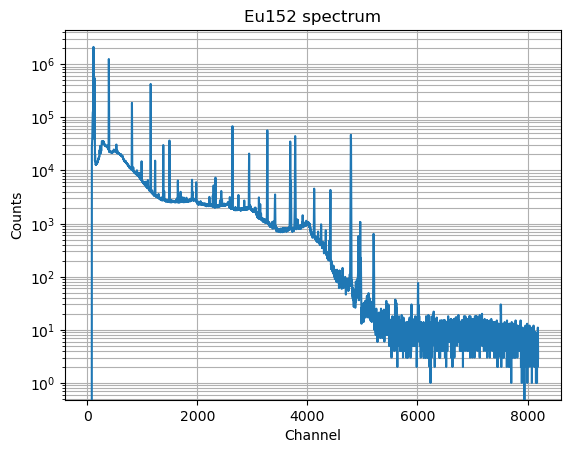

In [4]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Channel')
plt.ylabel('Counts')

## calibration generator

choose the obvious photobpeaks in the spectrum

uncomment here if you wat to see the what are the dominenent peaks in the spectrum

In [5]:
#import curie
#Eu152 =  curie.Isotope('EU-152')
#gamma_df = Eu152.gammas()
#gamma_df[gamma_df['intensity']>5]
#
#gamma_df = Eu152.gammas()
#gamma_df[gamma_df['intensity']>5]

In [6]:
domains = [(383, 403), (1140,1165), (2627, 2650), (3260,3285), (3680, 3695), (3770,3790), (4770, 4810)]
energies = [121.78, 344.28, 778.9, 964.08, 1085.8370, 1112.0760, 1408]
detector_calibration = DetectorCalibration(spectrum,
                                           known_axis_values=energies, peak_domains=domains,
                                          energy_model=PolynomialEnergyModel(2), fwhm_model=StandardHPGeFWHMModel())

In [7]:
energy_calib, fwhm_calib = detector_calibration.generate(energy_p0=(0,1,0), fwhm_p0=(0,1,0))

In [8]:
spectrum.set_axis_calibration(energy_calib)
spectrum.set_resolution_calibration(fwhm_calib)

Text(0, 0.5, 'Counts')

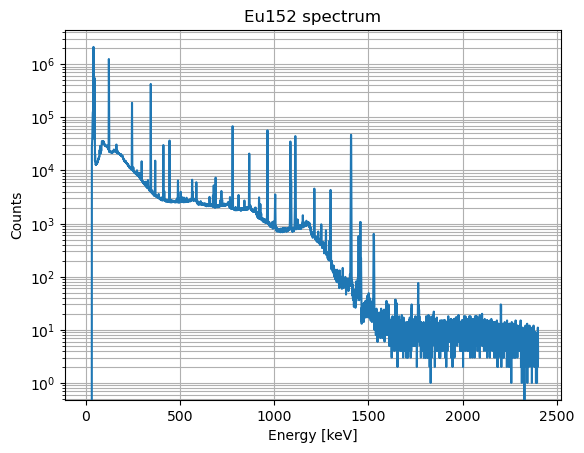

In [9]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')

In [10]:
import numpy as np
import xarray as xr
from pyspectrum.background.base import BackgroundEstimator
from pyspectrum.core.domain import Domain


class PolynomialBackground(BackgroundEstimator):
    def __init__(self, degree=3, max_iter=20):
        self.degree = degree
        self.max_iter = max_iter

    def estimate(self, spectrum, exclude_domains=None):
        x = spectrum.axis
        y = spectrum.counts.astype(float)

        # ---------------------------
        # Build mask
        # ---------------------------
        mask = np.ones_like(y, dtype=bool)

        if exclude_domains is not None:
            if isinstance(exclude_domains, Domain):
                exclude_domains = [exclude_domains]

            for domain in exclude_domains:
                mask[domain.start:domain.stop] = False

        # ---------------------------
        # Working copy
        # ---------------------------
        y_work = y.copy()

        # ---------------------------
        # Iterative ModPoly
        # ---------------------------
        for _ in range(self.max_iter):
            # Fit only on allowed points
            coeffs = np.polyfit(x[mask], y_work[mask], self.degree)

            # Evaluate on full axis
            fit = np.polyval(coeffs, x)

            # Clip only on allowed region
            y_work[mask] = np.minimum(y_work[mask], fit[mask])

        # Final polynomial (clean fit, no clipping)
        coeffs = np.polyfit(x[mask], y_work[mask], self.degree)
        background = np.polyval(coeffs, x)

        return xr.DataArray(
            background,
            coords={spectrum.axis_name: x},
            dims=[spectrum.axis_name],
            name="background"
        )

In [19]:
est = PolynomialBackground(degree=10, max_iter=10)

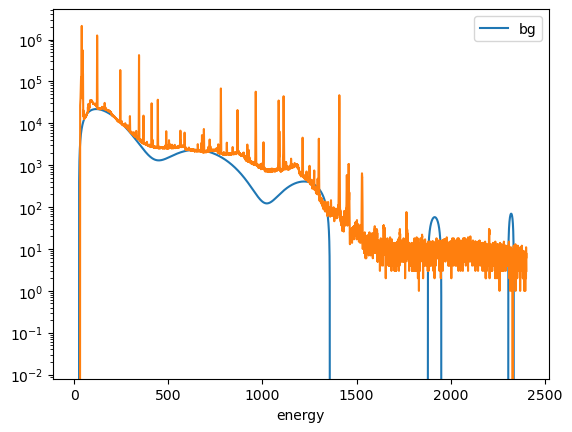

In [20]:
est.estimate(spectrum, exclude_domains=None).plot(label='bg')
spectrum.plot(yscale='log')
plt.legend()

find the calibration

In [9]:
detector_calibration = DetectorCalibration(spectrum,
                                           known_axis_values=energies, peak_domains=domains,
                                          energy_model=PolynomialEnergyModel(2), fwhm_model=StandardHPGeFWHMModel())
peaks_center_ch, fwhm_val = detector_calibration.estimate_peaks()

In [10]:
fwhm_energy_val = [spectrum.axis[int(ch_center+fwhm_val[i])]-spectrum.axis[int(ch_center)] for i, ch_center in enumerate(np.round(peaks_center_ch))]

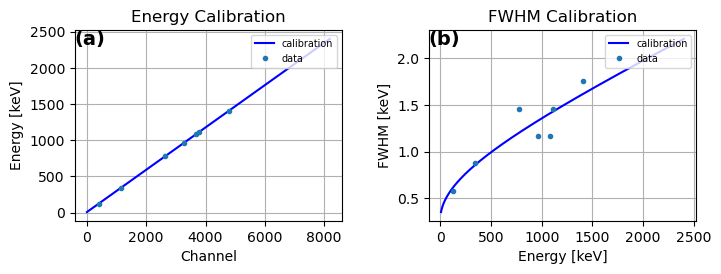

In [11]:
# === Create Side-by-Side Figure ===
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(7.1, 2.625), constrained_layout=True, gridspec_kw={'wspace': 0.1} )

# === Left plot: Energy Calibration ===
ax1.plot(spectrum.channels, spectrum.axis_calib.apply(spectrum.channels), 'b-', label='calibration')
ax1.plot(peaks_center_ch, spectrum.axis_calib.apply(peaks_center_ch), marker='.', ls='', label='data')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Energy [keV]')
ax1.set_title('Energy Calibration')
ax1.grid(which='both')
ax1.legend(fontsize='x-small', loc='upper right', frameon=True)
ax1.text(0, 1, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')

# === Right plot: FWHM  ===
ax2.plot(spectrum.axis_calib.apply(spectrum.channels), spectrum.resolution_calib.apply(spectrum.axis_calib.apply(spectrum.channels)), 'b-', label='calibration')
ax2.plot(energies, fwhm_energy_val, marker='.', ls='', label='data')
ax2.set_xlabel('Energy [keV]')
ax2.set_ylabel('FWHM [keV]')
ax2.set_title('FWHM Calibration')
ax2.grid(which='both')
ax2.legend(fontsize='x-small', loc='upper right', frameon=True)
ax2.text(0, 1.0, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')

# === Show ===
plt.show()


# Operations

Note that the spectrum object can be treated as an xarray (mostly)\
This means it can be normlized and operated easly

Text(0, 0.5, 'Counts rate [cps]')

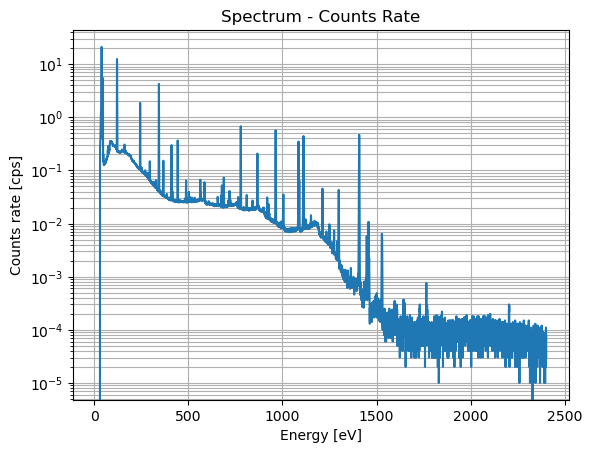

In [12]:
measurement_time = 1e5
(spectrum/measurement_time).plot(yscale='log')
plt.grid(True, which='both')
plt.title('Spectrum - Counts Rate')
plt.xlabel('Energy [eV]')
plt.ylabel('Counts rate [cps]')

## findPeaks
An example how to find domains in which the counts are above snr

In [13]:
# identification of peaks
from pyspectrum.identification import Convolution
from pyspectrum.identification.snr import SNRFinder
from pyspectrum.identification.kernels.mexican_hat import gaussian_2_dev

In [17]:
conv = Convolution(resolution=spectrum.resolution_calib.apply, kernel=gaussian_2_dev, window_fwhm=4)
finder = SNRFinder(convolution=conv, n_sigma_signal_threshold=5, n_sigma_bg_threshold=2.5, persistence_factor=1)
domains = finder.find(spectrum)

(1000.0, 2000000.0)

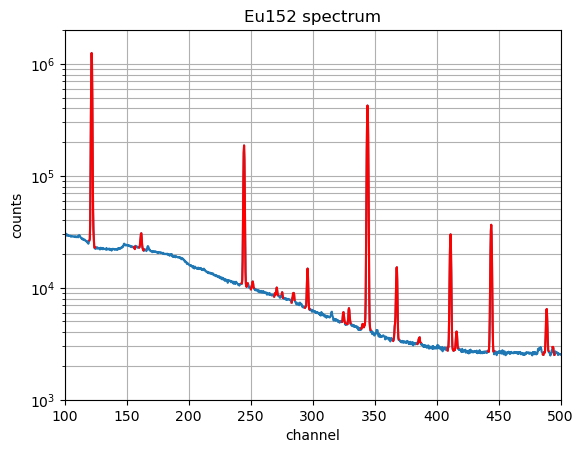

In [18]:
# note that using plot_all_peaks shows all the peaks in
plt.axes(yscale='log')
spectrum.plot()
for domain in domains:
    domain.plot(color='red')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('channel')
plt.ylabel('counts')
plt.xlim([100, 500])
plt.ylim([1e3, 2e6])

The peaks center can be found using the Mariscotti method

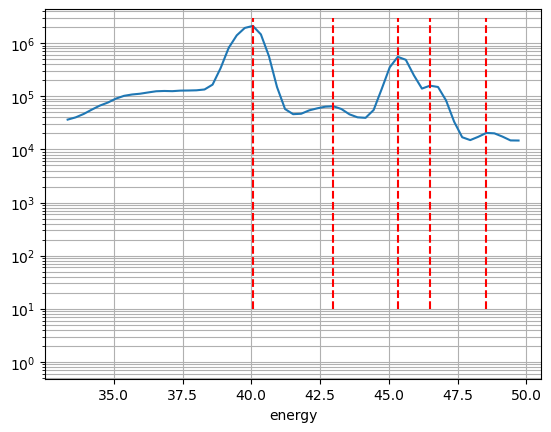

In [19]:
complex_domain = Domain(spectrum, start=91, stop=148)
complex_domain.plot(yscale='log')
minimal_statistical_accuracy = 0.05
resolution = spectrum.resolution_calib.apply(25) / (2 * np.sqrt(2 * np.log(2)))
minimal_counts_in_peak = 1 / minimal_statistical_accuracy ** 2
minimal_prominence = minimal_counts_in_peak / (0.761438079 * np.sqrt(2 * np.pi) * resolution)

#fp = FindPeaksCenters(spectrum.xr_spectrum().sel(energy=slice(24,51)), resolution/4, minimal_prominence)
for c in peak_positions(complex_domain, smooth=True, prominence=minimal_prominence):
    plt.vlines(ymax=3e6, ymin=10, x=c, color='red', ls='--')
plt.grid(True, which='both')